# Danh gia mo hinh Classification voi Optuna

Notebook nay huan luyen va danh gia 9 mo hinh classification theo yeu cau:

1. Random Forest voi toi uu sieu tham so bang Optuna
2. Extra Trees
3. Stacking/Blending: Random Forest + Extra Trees + Ridge
4. Balanced Random Forest
5. Gradient Boosting Machine
6. XGBoost
7. CatBoost
8. SHAP Top Features + Random Forest
9. Random Forest Voting Ensemble

Moi mo hinh duoc toi uu bang Optuna Bayesian/TPE Optimization, sau do danh gia tren tap test bang cac chi so:

- Accuracy (Acc)
- Precision (Pre)
- Recall
- F1-score

Rieng mo hinh SHAP Top Features + Random Forest dung SHAP tren tap train de chon cac feature quan trong nhat, roi huan luyen Random Forest chi tren cac feature nay nham giam nhieu va tang interpretability.

Mo hinh Random Forest Voting Ensemble ket hop nhieu Random Forest co cau hinh khac nhau bang soft voting de lay trung binh xac suat du doan.

Cuoi notebook co bang tong hop gom model, chi so danh gia, CV score tot nhat, so luong feature su dung va bo sieu tham so toi uu.


## 1. Cài đặt thư viện trên Colab

Chạy cell này khi dùng Google Colab. Nếu môi trường đã có sẵn thư viện thì lệnh vẫn an toàn.

In [ ]:
# Cai thu vien can thiet cho Colab
%pip -q install optuna xgboost imbalanced-learn catboost shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.5 MB/s eta 0:00:00


## 2. Import thư viện và cấu hình chung

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import optuna
import shap

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
THRESHOLD = 0.5
N_TRIALS = 30
CV_FOLDS = 3
OPTIMIZATION_METRIC = "F1-score"
SHAP_TOP_N_FEATURES = 10
SHAP_SAMPLE_SIZE = 300

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

Upload 4 file train/test t? folder `model_ready_data_threshold_25` ho?c `threshold_25_reprocessing/model_ready_data`:

- `X_train_balanced.csv`
- `y_train_balanced.csv`
- `X_test_scaled.csv`
- `y_test.csv`

Sau khi upload, notebook s? t? t?o folder `/content/model_ready_data`. Folder n?y ph?i l? b? d? li?u ?? g?n nh?n b?ng threshold 25%.


In [ ]:
# Ch?y cell n?y tr?n Google Colab n?u mu?n upload file CSV tr?c ti?p t? m?y t?nh.
# N?u b?n ?? mount Google Drive ho?c ?? c? s?n folder model_ready_data, c? th? b? qua cell n?y.

try:
    from google.colab import files

    UPLOAD_DIR = Path('/content/model_ready_data')
    UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

    required_files = {
        'X_train_balanced.csv',
        'y_train_balanced.csv',
        'X_test_scaled.csv',
        'y_test.csv',
    }

    print('H?y ch?n 4 file CSV model-ready t? m?y t?nh:')
    print(sorted(required_files))

    uploaded = files.upload()

    for filename, file_bytes in uploaded.items():
        target_path = UPLOAD_DIR / filename
        with open(target_path, 'wb') as f:
            f.write(file_bytes)

    uploaded_names = set(uploaded.keys())
    missing_files = required_files - uploaded_names

    print('?? upload v?o:', UPLOAD_DIR.resolve())
    print('File ?? upload:', sorted(uploaded_names))

    if missing_files:
        print('C?nh b?o: c?n thi?u file:', sorted(missing_files))
    else:
        print('?? ?? 4 file c?n thi?t. C? th? ch?y ti?p cell Load d? li?u model-ready.')

except ModuleNotFoundError:
    print('Cell n?y ch? ch?y tr?n Google Colab. N?u ?ang ch?y local/Jupyter, h?y ??t file threshold 25% v?o folder model_ready_data_threshold_25 ho?c model_ready_data th? c?ng.')

H?y ch?n 4 file CSV model-ready t? m?y t?nh:
['X_test_scaled.csv', 'X_train_balanced.csv', 'y_test.csv', 'y_train_balanced.csv']


Saving preprocessing_summary.json to preprocessing_summary.json
Saving README_model_ready_threshold_25.txt to README_model_ready_threshold_25.txt
Saving train_test_label_distribution.csv to train_test_label_distribution.csv
Saving X_test_scaled.csv to X_test_scaled.csv
Saving X_train_balanced.csv to X_train_balanced.csv
Saving X_train_scaled.csv to X_train_scaled.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv
Saving y_train_balanced.csv to y_train_balanced.csv
?? upload v?o: /content/model_ready_data
File ?? upload: ['README_model_ready_threshold_25.txt', 'X_test_scaled.csv', 'X_train_balanced.csv', 'X_train_scaled.csv', 'preprocessing_summary.json', 'train_test_label_distribution.csv', 'y_test.csv', 'y_train.csv', 'y_train_balanced.csv']
?? ?? 4 file c?n thi?t. C? th? ch?y ti?p cell Load d? li?u model-ready.


## 4. Load dữ liệu model-ready

Notebook ưu tiên dùng dữ liệu đã xử lý theo threshold cân bằng:

- preprocessing_notebook_output/balanced_threshold_reprocessing/model_ready_data

Nếu bạn upload riêng folder model_ready_data lên Colab, notebook cũng tự tìm được.

In [ ]:
# Nếu dùng Google Drive, có thể bật các dòng sau và chỉnh đường dẫn:
# from google.colab import drive
# drive.mount('/content/drive')
# MODEL_READY_DIR = Path('/content/drive/MyDrive/DSS/preprocessing_notebook_output/model_ready_data_threshold_25')

candidate_dirs = [
    Path('/content/model_ready_data'),
    Path('/content/model_ready_data_threshold_25'),
    Path('/content/preprocessing_notebook_output/model_ready_data_threshold_25'),
    Path('/content/preprocessing_notebook_output/threshold_25_reprocessing/model_ready_data'),
    Path.cwd() / 'model_ready_data',
    Path.cwd() / 'model_ready_data_threshold_25',
    Path.cwd() / 'preprocessing_notebook_output' / 'model_ready_data_threshold_25',
    Path.cwd() / 'preprocessing_notebook_output' / 'threshold_25_reprocessing' / 'model_ready_data',
    Path('/content/balanced_threshold_reprocessing/model_ready_data'),
    Path('/content/preprocessing_notebook_output/balanced_threshold_reprocessing/model_ready_data'),
    Path('/content/preprocessing_notebook_output/model_ready_data'),
    Path.cwd() / 'balanced_threshold_reprocessing' / 'model_ready_data',
    Path.cwd() / 'preprocessing_notebook_output' / 'balanced_threshold_reprocessing' / 'model_ready_data',
    Path.cwd() / 'preprocessing_notebook_output' / 'model_ready_data',
]

MODEL_READY_DIR = next((p for p in candidate_dirs if p.exists()), None)

if MODEL_READY_DIR is None:
    raise FileNotFoundError(
        "Không tìm thấy folder model_ready_data. Hãy upload folder này lên Colab "
        "hoặc chỉnh MODEL_READY_DIR thủ công."
    )

print("MODEL_READY_DIR:", MODEL_READY_DIR.resolve())

X_train = pd.read_csv(MODEL_READY_DIR / 'X_train_balanced.csv')
y_train = pd.read_csv(MODEL_READY_DIR / 'y_train_balanced.csv').iloc[:, 0].astype(int)
X_test = pd.read_csv(MODEL_READY_DIR / 'X_test_scaled.csv')
y_test = pd.read_csv(MODEL_READY_DIR / 'y_test.csv').iloc[:, 0].astype(int)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

display(pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "train_rate": y_train.value_counts(normalize=True).sort_index().round(4),
    "test_count": y_test.value_counts().sort_index(),
    "test_rate": y_test.value_counts(normalize=True).sort_index().round(4),
}))

MODEL_READY_DIR: /content/model_ready_data
X_train: (955, 24)
y_train: (955,)
X_test: (239, 24)
y_test: (239,)


,train_count,train_rate,test_count,test_rate
Risk_Label,,,,
0,461,0.4827,115,0.4812
1,494,0.5173,124,0.5188


## 5. SHAP Feature Selection

Cell nay fit mot Random Forest selector tren tap train, tinh SHAP value cho lop 1, roi lay top feature quan trong nhat.

Luu y: SHAP chi dung tap train, khong dung tap test. Sau khi chon feature, model `SHAP Top Features + Random Forest` se train/test chi tren cac cot nay.


Top 8 feature duoc chon bang SHAP:
01. Amount
02. Quantity
03. City_LabelEncoded
04. State_LabelEncoded
05. PaymentMode_COD
06. PaymentMode_Debit Card
07. PaymentMode_Credit Card
08. Category_Electronics


,Feature,MeanAbsSHAP
0,Amount,0.045182
1,Quantity,0.036699
2,City_LabelEncoded,0.031773
3,State_LabelEncoded,0.021013
4,PaymentMode_COD,0.017886
5,PaymentMode_Debit Card,0.010067
6,PaymentMode_Credit Card,0.009343
7,Category_Electronics,0.009243


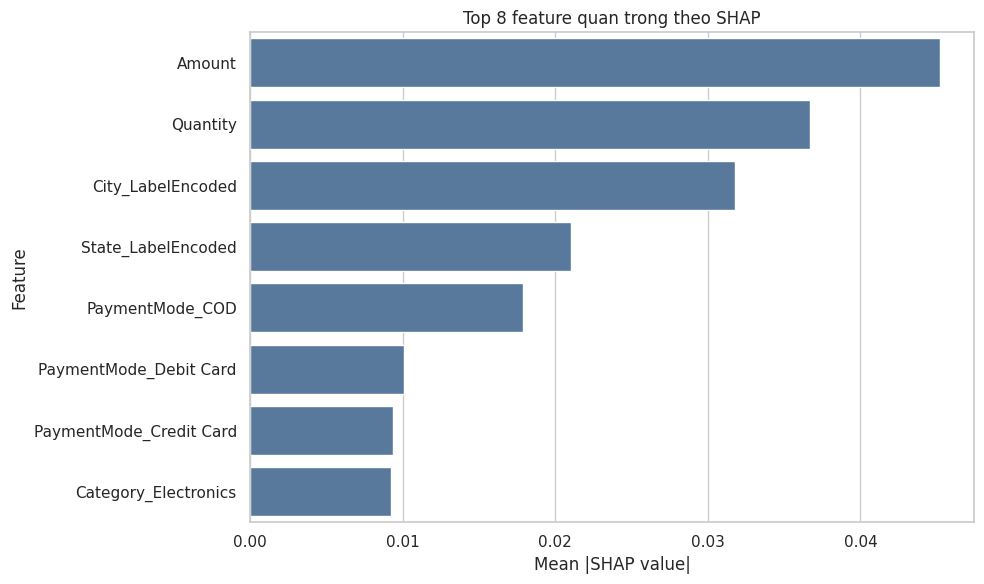

In [ ]:
# Random Forest selector de tinh SHAP feature importance tren tap train.
shap_selector_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
shap_selector_model.fit(X_train, y_train)

# Lay mau train de SHAP chay nhanh hon tren Colab.
# Neu muon tinh toan bo train, dat SHAP_SAMPLE_SIZE = len(X_train).
X_shap_sample = X_train.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_train)),
    random_state=RANDOM_STATE,
)

explainer = shap.TreeExplainer(shap_selector_model)
shap_values = explainer.shap_values(X_shap_sample)

# SHAP co the tra ve list [class_0, class_1] hoac array 3D tuy phien ban.
# Ta lay SHAP cua lop 1 vi day la nhan don hang an toan/lai tot.
if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
elif np.asarray(shap_values).ndim == 3:
    shap_values_class_1 = np.asarray(shap_values)[:, :, 1]
else:
    shap_values_class_1 = np.asarray(shap_values)

shap_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MeanAbsSHAP": np.abs(shap_values_class_1).mean(axis=0),
}).sort_values("MeanAbsSHAP", ascending=False).reset_index(drop=True)

SHAP_TOP_FEATURES = shap_importance_df.head(SHAP_TOP_N_FEATURES)["Feature"].tolist()

print(f"Top {len(SHAP_TOP_FEATURES)} feature duoc chon bang SHAP:")
for rank, feature in enumerate(SHAP_TOP_FEATURES, 1):
    print(f"{rank:02d}. {feature}")

display(shap_importance_df.head(SHAP_TOP_N_FEATURES))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=shap_importance_df.head(SHAP_TOP_N_FEATURES),
    x="MeanAbsSHAP",
    y="Feature",
    color="#4C78A8",
)
plt.title(f"Top {SHAP_TOP_N_FEATURES} feature quan trong theo SHAP")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 6. Ham tien ich danh gia model

Tất cả model đều dùng xác suất lớp 1 từ predict_proba()[:, 1], sau đó áp threshold để tạo nhãn dự đoán.

In [ ]:
def make_calibrated_classifier(base_estimator, method="sigmoid", cv=3):
    """Tạo CalibratedClassifierCV tương thích nhiều phiên bản scikit-learn."""
    try:
        return CalibratedClassifierCV(estimator=base_estimator, method=method, cv=cv)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=base_estimator, method=method, cv=cv)


def get_positive_class_probability(model, X):
    """Lấy xác suất dự đoán của lớp 1."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raise AttributeError(f"{model.__class__.__name__} không hỗ trợ predict_proba().")


def probability_to_label(y_pred_proba, threshold=THRESHOLD):
    """Chuyển xác suất thành nhãn 0/1."""
    return (np.asarray(y_pred_proba).reshape(-1) >= threshold).astype(int)


def calculate_metrics(y_true, y_pred_label):
    """Tính các chỉ số Acc, Pre, Recall, F1-score."""
    return {
        "Acc": accuracy_score(y_true, y_pred_label),
        "Pre": precision_score(y_true, y_pred_label, zero_division=0),
        "Recall": recall_score(y_true, y_pred_label, zero_division=0),
        "F1-score": f1_score(y_true, y_pred_label, zero_division=0),
    }


def evaluate_fitted_model(model, X_test, y_test, threshold=THRESHOLD):
    """Đánh giá model đã fit trên tập test."""
    y_pred_proba = get_positive_class_probability(model, X_test)
    y_pred_label = probability_to_label(y_pred_proba, threshold=threshold)
    metrics = calculate_metrics(y_test, y_pred_label)
    metrics.update({
        "Threshold": threshold,
        "Pred_Min": float(np.min(y_pred_proba)),
        "Pred_Mean": float(np.mean(y_pred_proba)),
        "Pred_Max": float(np.max(y_pred_proba)),
    })
    return metrics, y_pred_proba, y_pred_label


def cross_validated_f1(estimator, X, y, threshold=THRESHOLD, cv_folds=CV_FOLDS):
    """Tính F1-score trung bình bằng Stratified K-Fold CV."""
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for train_idx, valid_idx in cv.split(X, y):
        X_fold_train = X.iloc[train_idx]
        X_fold_valid = X.iloc[valid_idx]
        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        fold_model = clone(estimator)
        fold_model.fit(X_fold_train, y_fold_train)
        y_valid_proba = get_positive_class_probability(fold_model, X_fold_valid)
        y_valid_pred = probability_to_label(y_valid_proba, threshold=threshold)
        scores.append(f1_score(y_fold_valid, y_valid_pred, zero_division=0))

    return float(np.mean(scores))

## 7. Khong gian tim kiem sieu tham so cho tung model

Cell này định nghĩa cách Optuna tạo model từ mỗi trial.

In [ ]:
MODEL_NAMES = [
    "Random Forest",
    "Extra Trees",
    "Stacking/Blending RF + Extra Trees + Ridge",
    "Balanced Random Forest",
    "Gradient Boosting Machine",
    "XGBoost",
    "CatBoost",
    "SHAP Top Features + Random Forest",
    "Random Forest Voting Ensemble",
]

ALL_FEATURES = X_train.columns.tolist()
if "SHAP_TOP_FEATURES" not in globals():
    raise RuntimeError("Hay chay cell SHAP feature selection truoc khi chay Optuna.")

MODEL_FEATURE_COLUMNS = {model_name: ALL_FEATURES for model_name in MODEL_NAMES}
MODEL_FEATURE_COLUMNS["SHAP Top Features + Random Forest"] = SHAP_TOP_FEATURES

print("So feature theo tung model:")
for model_name, feature_columns in MODEL_FEATURE_COLUMNS.items():
    print(f"- {model_name}: {len(feature_columns)} feature")


def build_model_from_trial(model_name, trial):
    """Tạo classifier theo model_name và siêu tham số do Optuna đề xuất."""
    if model_name in ["Random Forest", "SHAP Top Features + Random Forest"]:
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=100),
            max_depth=trial.suggest_categorical("max_depth", [None, 4, 6, 8, 10, 12, 16, 20]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            bootstrap=trial.suggest_categorical("bootstrap", [True, False]),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )


    if model_name == "Random Forest Voting Ensemble":
        n_estimators_each = trial.suggest_int("rf_vote_n_estimators_each", 100, 300, step=100)
        max_depth = trial.suggest_categorical("rf_vote_max_depth", [None, 4, 6, 8, 10, 12, 16])
        min_samples_split = trial.suggest_int("rf_vote_min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("rf_vote_min_samples_leaf", 1, 10)
        criterion = trial.suggest_categorical("rf_vote_criterion", ["gini", "entropy"])
        bootstrap = trial.suggest_categorical("rf_vote_bootstrap", [True, False])

        rf_main = RandomForestClassifier(
            n_estimators=n_estimators_each,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=trial.suggest_categorical("rf_vote_main_max_features", ["sqrt", "log2", None]),
            bootstrap=bootstrap,
            criterion=criterion,
            class_weight=trial.suggest_categorical("rf_vote_main_class_weight", [None, "balanced"]),
            random_state=RANDOM_STATE + 11,
            n_jobs=-1,
        )
        rf_balanced = RandomForestClassifier(
            n_estimators=n_estimators_each,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=trial.suggest_categorical("rf_vote_balanced_max_features", ["sqrt", "log2"]),
            bootstrap=bootstrap,
            criterion=criterion,
            class_weight="balanced",
            random_state=RANDOM_STATE + 22,
            n_jobs=-1,
        )
        rf_subspace = RandomForestClassifier(
            n_estimators=n_estimators_each,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=trial.suggest_categorical("rf_vote_subspace_max_features", ["sqrt", "log2"]),
            bootstrap=bootstrap,
            criterion=criterion,
            class_weight=trial.suggest_categorical("rf_vote_subspace_class_weight", [None, "balanced"]),
            random_state=RANDOM_STATE + 33,
            n_jobs=-1,
        )

        return VotingClassifier(
            estimators=[
                ("rf_main", rf_main),
                ("rf_balanced", rf_balanced),
                ("rf_subspace", rf_subspace),
            ],
            voting="soft",
            weights=[
                trial.suggest_int("rf_vote_weight_main", 1, 4),
                trial.suggest_int("rf_vote_weight_balanced", 1, 4),
                trial.suggest_int("rf_vote_weight_subspace", 1, 4),
            ],
            n_jobs=-1,
        )

    if model_name == "Extra Trees":
        return ExtraTreesClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=100),
            max_depth=trial.suggest_categorical("max_depth", [None, 4, 6, 8, 10, 12, 16, 20]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            bootstrap=trial.suggest_categorical("bootstrap", [True, False]),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    if model_name == "Stacking/Blending RF + Extra Trees + Ridge":
        rf = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 100, 400, step=100),
            max_depth=trial.suggest_categorical("rf_max_depth", [None, 4, 6, 8, 12]),
            min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 8),
            max_features=trial.suggest_categorical("rf_max_features", ["sqrt", "log2"]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        et = ExtraTreesClassifier(
            n_estimators=trial.suggest_int("et_n_estimators", 100, 400, step=100),
            max_depth=trial.suggest_categorical("et_max_depth", [None, 4, 6, 8, 12]),
            min_samples_leaf=trial.suggest_int("et_min_samples_leaf", 1, 8),
            max_features=trial.suggest_categorical("et_max_features", ["sqrt", "log2"]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        ridge_base = make_calibrated_classifier(
            RidgeClassifier(alpha=trial.suggest_float("ridge_alpha", 1e-3, 100.0, log=True)),
            method="sigmoid",
            cv=3,
        )
        final_estimator = make_calibrated_classifier(
            RidgeClassifier(alpha=trial.suggest_float("final_ridge_alpha", 1e-3, 100.0, log=True)),
            method="sigmoid",
            cv=3,
        )
        return StackingClassifier(
            estimators=[("rf", rf), ("extra_trees", et), ("ridge", ridge_base)],
            final_estimator=final_estimator,
            stack_method="predict_proba",
            cv=3,
            n_jobs=-1,
            passthrough=trial.suggest_categorical("passthrough", [False, True]),
        )

    if model_name == "Balanced Random Forest":
        return BalancedRandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=100),
            max_depth=trial.suggest_categorical("max_depth", [None, 4, 6, 8, 10, 12, 16, 20]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            sampling_strategy=trial.suggest_categorical("sampling_strategy", ["auto", "all"]),
            replacement=trial.suggest_categorical("replacement", [True, False]),
            bootstrap=trial.suggest_categorical("bootstrap", [True, False]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    if model_name == "Gradient Boosting Machine":
        return GradientBoostingClassifier(
            n_estimators=trial.suggest_int("n_estimators", 50, 500, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 6),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            random_state=RANDOM_STATE,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=100),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            min_child_weight=trial.suggest_float("min_child_weight", 1.0, 10.0),
            gamma=trial.suggest_float("gamma", 0.0, 5.0),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    if model_name == "CatBoost":
        return CatBoostClassifier(
            iterations=trial.suggest_int("iterations", 100, 600, step=100),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            depth=trial.suggest_int("depth", 3, 8),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1e-2, 30.0, log=True),
            random_strength=trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
            bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
            border_count=trial.suggest_categorical("border_count", [32, 64, 128, 254]),
            loss_function="Logloss",
            eval_metric="F1",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )


    raise ValueError(f"Chưa định nghĩa không gian tìm kiếm cho model: {model_name}")

So feature theo tung model:
- Random Forest: 24 feature
- Extra Trees: 24 feature
- Stacking/Blending RF + Extra Trees + Ridge: 24 feature
- Balanced Random Forest: 24 feature
- Gradient Boosting Machine: 24 feature
- XGBoost: 24 feature
- CatBoost: 24 feature
- SHAP Top Features + Random Forest: 8 feature
- Random Forest Voting Ensemble: 24 feature


## 8. Chay Optuna va danh gia tung model

Cell này là phần chạy chính. Có thể mất thời gian trên Colab, đặc biệt với Stacking/Blending và XGBoost.

Nếu muốn chạy nhanh để thử notebook, giảm N_TRIALS ở phần cấu hình.

In [ ]:
def optimize_one_model(model_name, n_trials=N_TRIALS):
    """Toi uu mot model bang Optuna tren dung tap feature cua model do."""
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    feature_columns = MODEL_FEATURE_COLUMNS.get(model_name, ALL_FEATURES)
    X_train_model = X_train[feature_columns]

    def objective(trial):
        model = build_model_from_trial(model_name, trial)
        return cross_validated_f1(
            model,
            X_train_model,
            y_train,
            threshold=THRESHOLD,
            cv_folds=CV_FOLDS,
        )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_model = build_model_from_trial(model_name, study.best_trial)
    return best_model, study, feature_columns


best_models = {}
predictions = {}
model_feature_sets = {}
metrics_rows = []
tuning_rows = []

for model_name in MODEL_NAMES:
    print("=" * 100)
    print(f"Đang tối ưu và đánh giá: {model_name}")
    print("=" * 100)

    best_model, study, feature_columns = optimize_one_model(model_name, n_trials=N_TRIALS)
    X_train_model = X_train[feature_columns]
    X_test_model = X_test[feature_columns]

    best_model.fit(X_train_model, y_train)

    test_metrics, y_pred_proba, y_pred_label = evaluate_fitted_model(
        best_model,
        X_test_model,
        y_test,
        threshold=THRESHOLD,
    )

    best_models[model_name] = best_model
    model_feature_sets[model_name] = feature_columns
    predictions[model_name] = {
        "proba": y_pred_proba,
        "label": y_pred_label,
    }

    metrics_rows.append({
        "Model": model_name,
        **test_metrics,
        "Best_CV_F1": study.best_value,
        "Feature_Count": len(feature_columns),
        "Selected_Features": ", ".join(feature_columns),
    })
    tuning_rows.append({
        "Model": model_name,
        "Best_CV_F1": study.best_value,
        "Best_Params": study.best_params,
        "N_Trials": len(study.trials),
        "Feature_Count": len(feature_columns),
        "Selected_Features": ", ".join(feature_columns),
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[[
    "Model",
    "Acc",
    "Pre",
    "Recall",
    "F1-score",
    "Best_CV_F1",
    "Feature_Count",
    "Threshold",
    "Pred_Min",
    "Pred_Mean",
    "Pred_Max",
]]
metrics_df = metrics_df.sort_values(["F1-score", "Recall", "Acc"], ascending=False).reset_index(drop=True)

tuning_results_df = pd.DataFrame(tuning_rows).sort_values("Best_CV_F1", ascending=False).reset_index(drop=True)

best_params_table = pd.json_normalize(tuning_results_df["Best_Params"])
best_params_table.insert(0, "Model", tuning_results_df["Model"].to_numpy())
best_params_table.insert(1, "Best_CV_F1", tuning_results_df["Best_CV_F1"].to_numpy())
best_params_table.insert(2, "Feature_Count", tuning_results_df["Feature_Count"].to_numpy())
best_params_table.insert(3, "Selected_Features", tuning_results_df["Selected_Features"].to_numpy())
best_params_table = best_params_table.fillna("")

final_summary_df = metrics_df.merge(
    tuning_results_df[["Model", "Best_Params", "N_Trials", "Selected_Features"]],
    on="Model",
    how="left",
)

print("Bảng metrics trên tập test:")
display(metrics_df.style.format({
    "Acc": "{:.4f}",
    "Pre": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "Best_CV_F1": "{:.4f}",
    "Feature_Count": "{:.0f}",
    "Threshold": "{:.2f}",
    "Pred_Min": "{:.4f}",
    "Pred_Mean": "{:.4f}",
    "Pred_Max": "{:.4f}",
}))

print("Bảng siêu tham số tối ưu dạng phẳng:")
display(best_params_table)

print("Bảng tổng hợp cuối cùng:")
display(final_summary_df)

Đang tối ưu và đánh giá: Random Forest


  0%|          | 0/30 [00:00<?, ?it/s]

Đang tối ưu và đánh giá: Extra Trees


  0%|          | 0/30 [00:00<?, ?it/s]

Đang tối ưu và đánh giá: Stacking/Blending RF + Extra Trees + Ridge


...

,Model,Acc,Pre,Recall,F1-score,Best_CV_F1,Feature_Count,Threshold,Pred_Min,Pred_Mean,Pred_Max
0,CatBoost,0.6904,0.7119,0.6774,0.6942,0.6686,24,0.50,0.0039,0.5038,0.9965
1,Gradient Boosting Machine,0.6695,0.7064,0.6210,0.6609,0.6579,24,0.50,0.0065,0.4645,0.9964
2,Balanced Random Forest,0.6527,0.6847,0.6129,0.6468,0.6177,24,0.50,0.0092,0.4841,1.0000
3,Stacking/Blending RF + Extra Trees + Ridge,0.5230,0.5272,0.7823,0.6299,0.6347,24,0.50,0.4515,0.5178,0.5688
4,XGBoost,0.6402,0.6827,0.5726,0.6228,0.6211,24,0.50,0.0175,0.4932,0.9818
5,Random Forest Voting Ensemble,0.6318,0.6667,0.5806,0.6207,0.6116,24,0.50,0.1161,0.4911,0.8692
6,SHAP Top Features + Random Forest,0.6151,0.6356,0.6048,0.6198,0.6173,8,0.50,0.1084,0.5022,0.9738
7,Random Forest,0.6276,0.6699,0.5565,0.6079,0.6212,24,0.50,0.1679,0.4977,0.9756
8,Extra Trees,0.5230,0.5305,0.7016,0.6042,0.5965,24,0.50,0.2968,0.5186,0.6644


Bảng siêu tham số tối ưu dạng phẳng:


,Model,Best_CV_F1,Feature_Count,Selected_Features,iterations,learning_rate,depth,l2_leaf_reg,random_strength,bagging_temperature,border_count,n_estimators,max_depth,min_samples_split,min_samples_leaf,subsample,max_features,rf_n_estimators,rf_max_depth,rf_min_samples_leaf,rf_max_features,et_n_estimators,et_max_depth,et_min_samples_leaf,et_max_features,ridge_alpha,final_ridge_alpha,passthrough,bootstrap,class_weight,min_child_weight,gamma,colsample_bytree,reg_alpha,reg_lambda,sampling_strategy,replacement,rf_vote_n_estimators_each,rf_vote_max_depth,rf_vote_min_samples_split,rf_vote_min_samples_leaf,rf_vote_criterion,rf_vote_bootstrap,rf_vote_main_max_features,rf_vote_main_class_weight,rf_vote_balanced_max_features,rf_vote_subspace_max_features,rf_vote_subspace_class_weight,rf_vote_weight_main,rf_vote_weight_balanced,rf_vote_weight_subspace
0,CatBoost,0.668564,24,"Quantity, Amount, PaymentMode_COD, PaymentMode...",400.0,0.053673,6.0,0.030386,0.046145,0.334336,254.0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Gradient Boosting Machine,0.657854,24,"Quantity, Amount, PaymentMode_COD, PaymentMode...",,0.063143,,,,,,400.0,6.0,2.0,1.0,0.722629,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,Stacking/Blending RF + Extra Trees + Ridge,0.634692,24,"Quantity, Amount, PaymentMode_COD, PaymentMode...",,,,,,,,,,,,,,200.0,12.0,4.0,sqrt,300.0,6.0,7.0,log2,0.219634,76.456913,True,,,,,,,,,,,,,,,,,,,,,,,
3,Random Forest,0.621202,24,"Quantity, Amount, PaymentMode_COD, PaymentMode...",,,,,,,,300.0,10.0,9.0,2.0,,,,,,,,,,,,,,True,,,,,,,,,,,,,,,,,,,,,,
4,XGBoost,0.621100,24,"Quantity, Amount, PaymentMode_COD, PaymentMode...",,0.130631,,,,,,100.0,8.0,,,0.806411,,,,,,,,,,,,,,,1.022904,0.01456,0.71198,0.000032,0.727635,,,,,,,,,,,,,,,,
5,Balanced Random Forest,0.617660,24,"Quantity, Amount, PaymentMode_COD, PaymentMode...",,,,,,,,600.0,12.0,12.0,5.0,,,,,,,,,,,,,,False,,,,,,,auto,False,,,,,,,,,,,,,,
6,SHAP Top Features + Random Forest,0.617313,8,"Amount, Quantity, City_LabelEncoded, State_Lab...",,,,,,,,400.0,20.0,9.0,4.0,,,,,,,,,,,,,,True,,,,,,,,,,,,,,,,,,,,,,
7,Random Forest Voting Ensemble,0.611553,24,"Quantity, Amount, PaymentMode_COD, PaymentMode...",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,200.0,12.0,5.0,2.0,gini,False,sqrt,,sqrt,log2,,2.0,4.0,4.0
8,Extra Trees,0.596460,24,"Quantity, Amount, PaymentMode_COD, PaymentMode...",,,,,,,,600.0,4.0,13.0,5.0,,,,,,,,,,,,,,False,,,,,,,,,,,,,,,,,,,,,,


Bảng tổng hợp cuối cùng:


,Model,Acc,Pre,Recall,F1-score,Best_CV_F1,Feature_Count,Threshold,Pred_Min,Pred_Mean,Pred_Max,Best_Params,N_Trials,Selected_Features
0,CatBoost,0.690377,0.711864,0.677419,0.694215,0.668564,24,0.5,0.003913,0.503823,0.996513,"{'iterations': 400, 'learning_rate': 0.0536734...",30,"Quantity, Amount, PaymentMode_COD, PaymentMode..."
1,Gradient Boosting Machine,0.669456,0.706422,0.620968,0.660944,0.657854,24,0.5,0.006540,0.464507,0.996383,"{'n_estimators': 400, 'learning_rate': 0.06314...",30,"Quantity, Amount, PaymentMode_COD, PaymentMode..."
2,Balanced Random Forest,0.652720,0.684685,0.612903,0.646809,0.617660,24,0.5,0.009213,0.484051,1.000000,"{'n_estimators': 600, 'max_depth': 12, 'min_sa...",30,"Quantity, Amount, PaymentMode_COD, PaymentMode..."
3,Stacking/Blending RF + Extra Trees + Ridge,0.523013,0.527174,0.782258,0.629870,0.634692,24,0.5,0.451489,0.517781,0.568826,"{'rf_n_estimators': 200, 'rf_max_depth': 12, '...",30,"Quantity, Amount, PaymentMode_COD, PaymentMode..."
4,XGBoost,0.640167,0.682692,0.572581,0.622807,0.621100,24,0.5,0.017476,0.493235,0.981804,"{'n_estimators': 100, 'learning_rate': 0.13063...",30,"Quantity, Amount, PaymentMode_COD, PaymentMode..."
5,Random Forest Voting Ensemble,0.631799,0.666667,0.580645,0.620690,0.611553,24,0.5,0.116061,0.491133,0.869195,"{'rf_vote_n_estimators_each': 200, 'rf_vote_ma...",30,"Quantity, Amount, PaymentMode_COD, PaymentMode..."
6,SHAP Top Features + Random Forest,0.615063,0.635593,0.604839,0.619835,0.617313,8,0.5,0.108425,0.502236,0.973763,"{'n_estimators': 400, 'max_depth': 20, 'min_sa...",30,"Amount, Quantity, City_LabelEncoded, State_Lab..."
7,Random Forest,0.627615,0.669903,0.556452,0.607930,0.621202,24,0.5,0.167936,0.497707,0.975622,"{'n_estimators': 300, 'max_depth': 10, 'min_sa...",30,"Quantity, Amount, PaymentMode_COD, PaymentMode..."
8,Extra Trees,0.523013,0.530488,0.701613,0.604167,0.596460,24,0.5,0.296814,0.518607,0.664405,"{'n_estimators': 600, 'max_depth': 4, 'min_sam...",30,"Quantity, Amount, PaymentMode_COD, PaymentMode..."


In [ ]:
if 'final_summary_df' in globals():
    display(final_summary_df)
else:
    print("Biến 'final_summary_df' chưa được định nghĩa. Vui lòng chạy lại cell tối ưu hóa (cell ID: -VJdOX-yJABv) để khởi tạo dữ liệu.")

Biến 'final_summary_df' chưa được định nghĩa. Vui lòng chạy lại cell tối ưu hóa (cell ID: -VJdOX-yJABv) để khởi tạo dữ liệu.


## 9. Bang tong hop cuoi cung

Cell này hiển thị lại bảng tổng hợp sau khi đã tối ưu và đánh giá.

In [ ]:
display(final_summary_df[[
    "Model",
    "Acc",
    "Pre",
    "Recall",
    "F1-score",
    "Best_CV_F1",
    "Feature_Count",
    "Threshold",
    "Selected_Features",
    "Best_Params",
]].style.format({
    "Acc": "{:.4f}",
    "Pre": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "Best_CV_F1": "{:.4f}",
    "Feature_Count": "{:.0f}",
    "Threshold": "{:.2f}",
}))

,Model,Acc,Pre,Recall,F1-score,Best_CV_F1,Feature_Count,Threshold,Selected_Features,Best_Params
0,CatBoost,0.6904,0.7119,0.6774,0.6942,0.6686,24,0.50,"Quantity, Amount, PaymentMode_COD, PaymentMode_Credit Card, PaymentMode_Debit Card, PaymentMode_EMI, PaymentMode_UPI, Category_Electronics, Category_Furniture, Category_Office Supplies, Sub-Category_Binders, Sub-Category_Bookcases, Sub-Category_Chairs, Sub-Category_Electronic Games, Sub-Category_Laptops, Sub-Category_Markers, Sub-Category_Paper, Sub-Category_Pens, Sub-Category_Phones, Sub-Category_Printers, Sub-Category_Sofas, Sub-Category_Tables, State_LabelEncoded, City_LabelEncoded","{'iterations': 400, 'learning_rate': 0.05367348098271405, 'depth': 6, 'l2_leaf_reg': 0.030385687558382078, 'random_strength': 0.04614512934665785, 'bagging_temperature': 0.33433608718412866, 'border_count': 254}"
1,Gradient Boosting Machine,0.6695,0.7064,0.6210,0.6609,0.6579,24,0.50,"Quantity, Amount, PaymentMode_COD, PaymentMode_Credit Card, PaymentMode_Debit Card, PaymentMode_EMI, PaymentMode_UPI, Category_Electronics, Category_Furniture, Category_Office Supplies, Sub-Category_Binders, Sub-Category_Bookcases, Sub-Category_Chairs, Sub-Category_Electronic Games, Sub-Category_Laptops, Sub-Category_Markers, Sub-Category_Paper, Sub-Category_Pens, Sub-Category_Phones, Sub-Category_Printers, Sub-Category_Sofas, Sub-Category_Tables, State_LabelEncoded, City_LabelEncoded","{'n_estimators': 400, 'learning_rate': 0.06314348458287034, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 1, 'subsample': 0.7226291768672877, 'max_features': None}"
2,Balanced Random Forest,0.6527,0.6847,0.6129,0.6468,0.6177,24,0.50,"Quantity, Amount, PaymentMode_COD, PaymentMode_Credit Card, PaymentMode_Debit Card, PaymentMode_EMI, PaymentMode_UPI, Category_Electronics, Category_Furniture, Category_Office Supplies, Sub-Category_Binders, Sub-Category_Bookcases, Sub-Category_Chairs, Sub-Category_Electronic Games, Sub-Category_Laptops, Sub-Category_Markers, Sub-Category_Paper, Sub-Category_Pens, Sub-Category_Phones, Sub-Category_Printers, Sub-Category_Sofas, Sub-Category_Tables, State_LabelEncoded, City_LabelEncoded","{'n_estimators': 600, 'max_depth': 12, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': None, 'sampling_strategy': 'auto', 'replacement': False, 'bootstrap': False}"
3,Stacking/Blending RF + Extra Trees + Ridge,0.5230,0.5272,0.7823,0.6299,0.6347,24,0.50,"Quantity, Amount, PaymentMode_COD, PaymentMode_Credit Card, PaymentMode_Debit Card, PaymentMode_EMI, PaymentMode_UPI, Category_Electronics, Category_Furniture, Category_Office Supplies, Sub-Category_Binders, Sub-Category_Bookcases, Sub-Category_Chairs, Sub-Category_Electronic Games, Sub-Category_Laptops, Sub-Category_Markers, Sub-Category_Paper, Sub-Category_Pens, Sub-Category_Phones, Sub-Category_Printers, Sub-Category_Sofas, Sub-Category_Tables, State_LabelEncoded, City_LabelEncoded","{'rf_n_estimators': 200, 'rf_max_depth': 12, 'rf_min_samples_leaf': 4, 'rf_max_features': 'sqrt', 'et_n_estimators': 300, 'et_max_depth': 6, 'et_min_samples_leaf': 7, 'et_max_features': 'log2', 'ridge_alpha': 0.2196339095862011, 'final_ridge_alpha': 76.4569128683383, 'passthrough': True}"
4,XGBoost,0.6402,0.6827,0.5726,0.6228,0.6211,24,0.50,"Quantity, Amount, PaymentMode_COD, PaymentMode_Credit Card, PaymentMode_Debit Card, PaymentMode_EMI, PaymentMode_UPI, Category_Electronics, Category_Furniture, Category_Office Supplies, Sub-Category_Binders, Sub-Category_Bookcases, Sub-Category_Chairs, Sub-Category_Electronic Games, Sub-Category_Laptops, Sub-Category_Markers, Sub-Category_Paper, Sub-Category_Pens, Sub-Category_Phones, Sub-Category_Printers, Sub-Category_Sofas, Sub-Category_Tables, State_LabelEncoded, City_LabelEncoded","{'n_estimators': 100, 'learning_rate': 0.1306311857308519, 'max_depth': 8, 'min_child_weight': 1.0229039590812214, 'gamma': 0.014560051001811708, 'subsample': 0.8064114554738083, 'colsample_bytree': 0.7119802868481923, 'reg_alpha': 3.15444350

## 10. Bieu do so sanh chi so


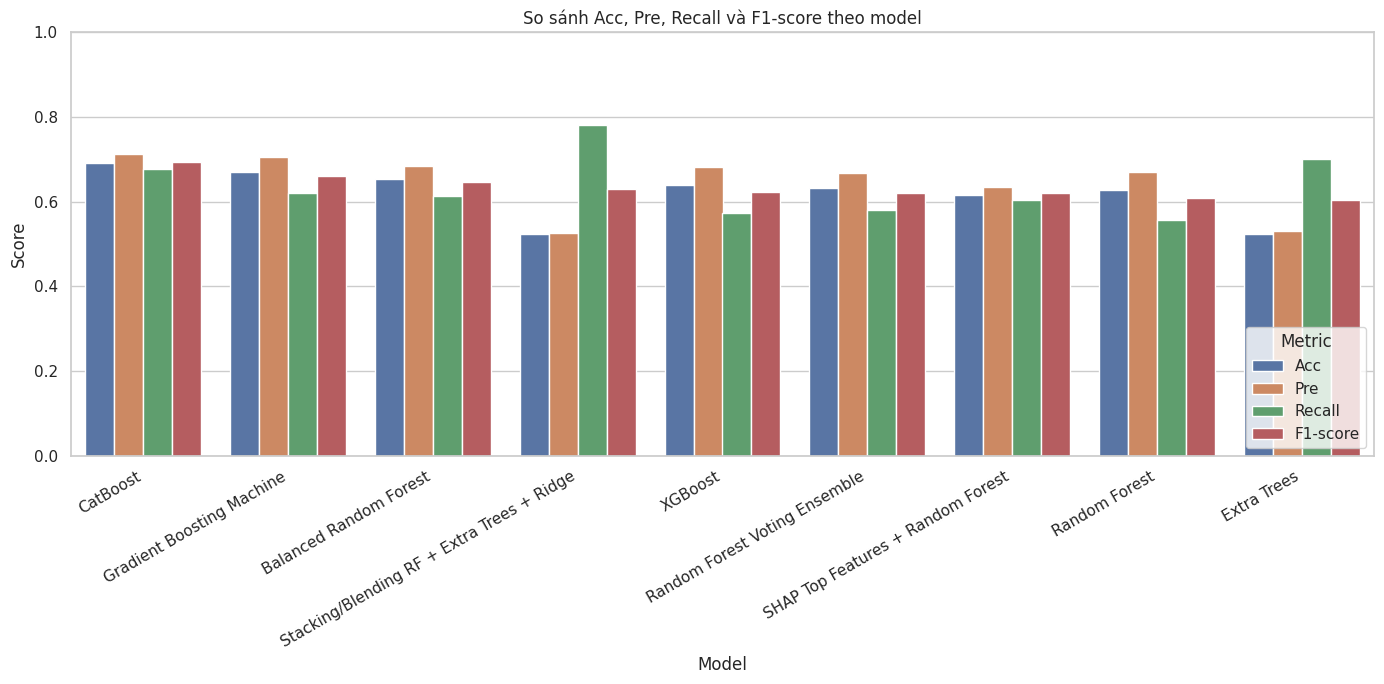

In [ ]:
plot_df = metrics_df.melt(
    id_vars=["Model"],
    value_vars=["Acc", "Pre", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.title("So sánh Acc, Pre, Recall và F1-score theo model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.show()

## 11. Confusion Matrix cho tung model


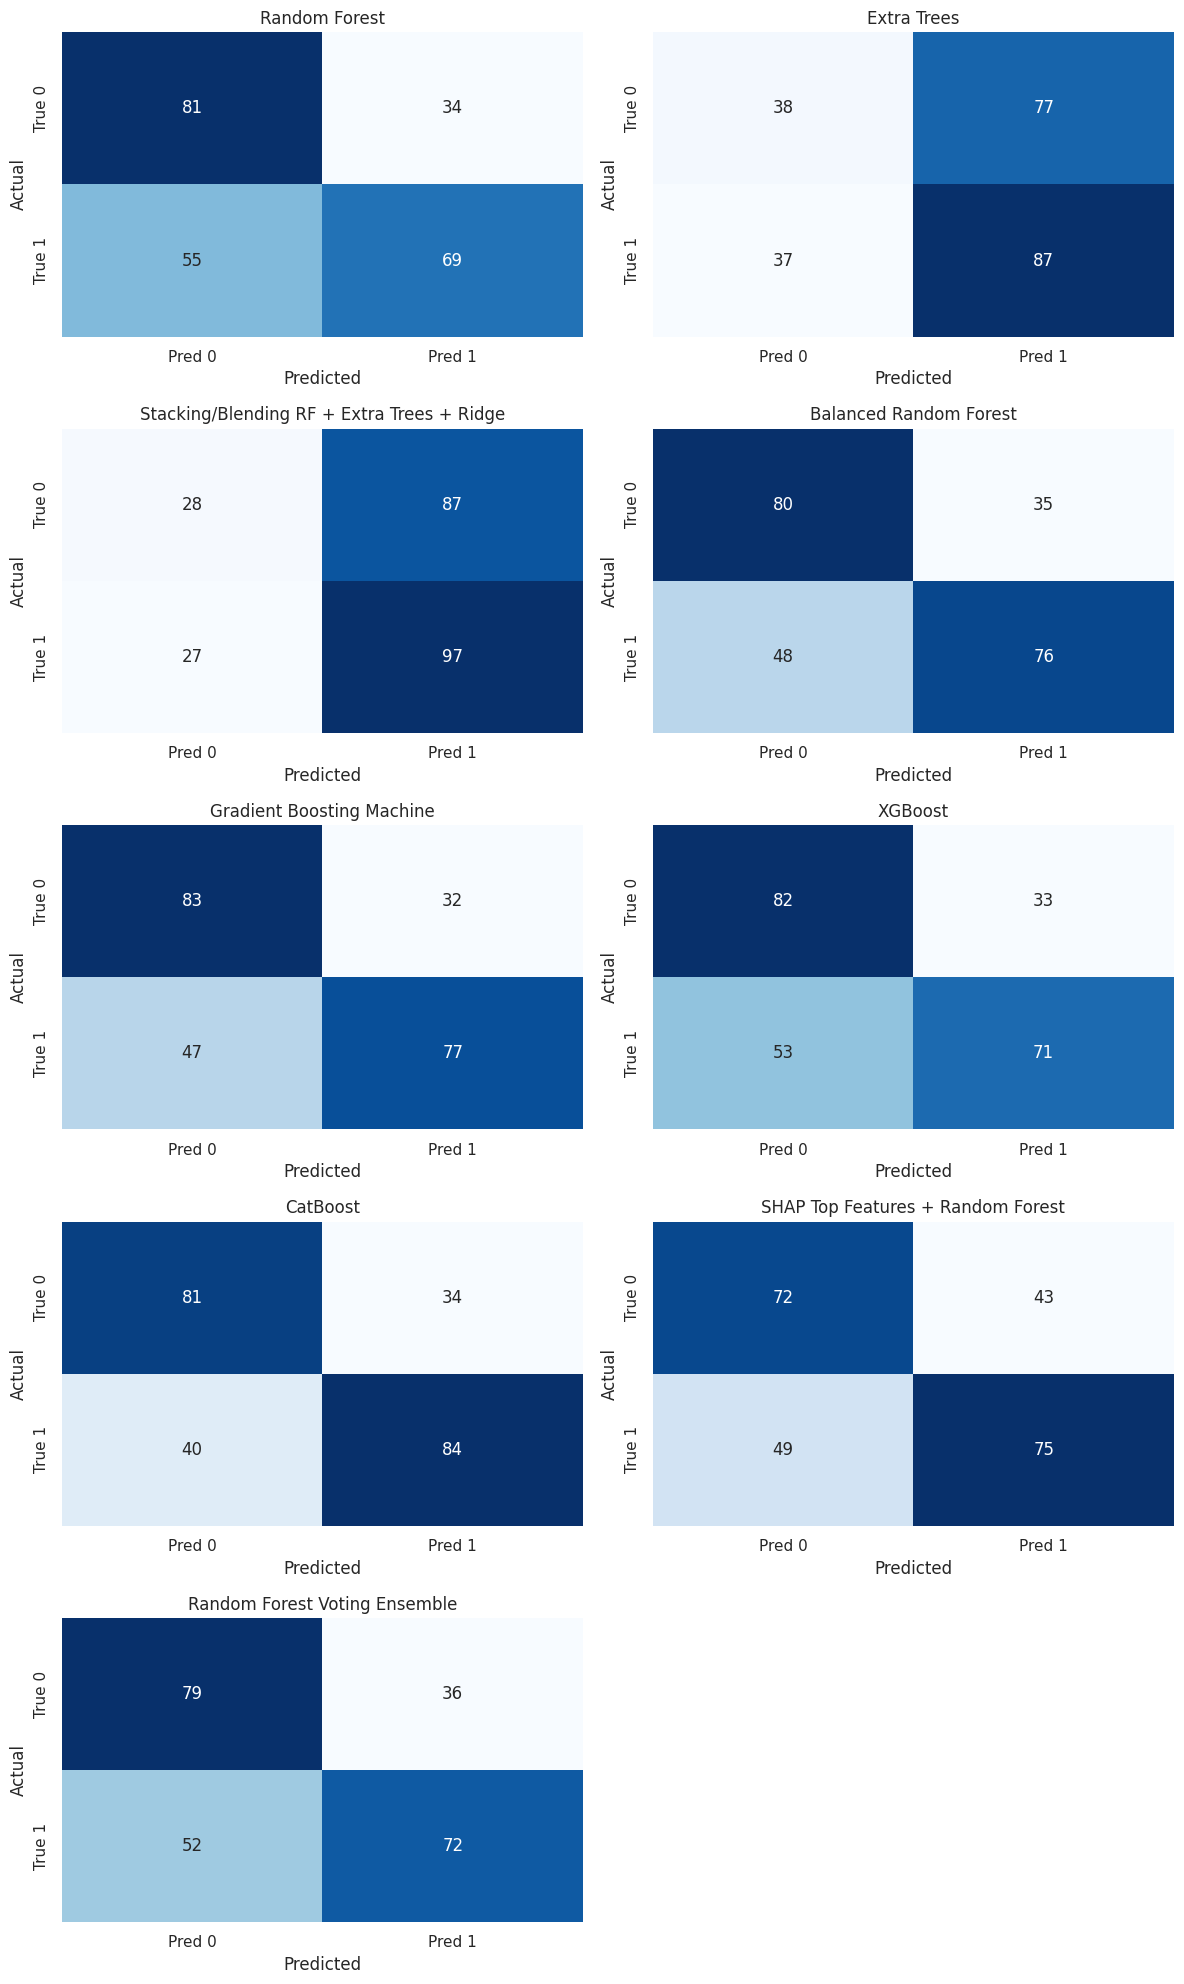

In [ ]:
n_models = len(MODEL_NAMES)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, MODEL_NAMES):
    cm = confusion_matrix(y_test, predictions[model_name]["label"], labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 12. Classification Report chi tiet


In [ ]:
for model_name in MODEL_NAMES:
    print("=" * 100)
    print(model_name)
    print("=" * 100)
    print(classification_report(
        y_test,
        predictions[model_name]["label"],
        labels=[0, 1],
        target_names=["0 - Rủi ro", "1 - An toàn"],
        zero_division=0,
    ))

Random Forest
              precision    recall  f1-score   support

  0 - Rủi ro       0.60      0.70      0.65       115
 1 - An toàn       0.67      0.56      0.61       124

    accuracy                           0.63       239
   macro avg       0.63      0.63      0.63       239
weighted avg       0.63      0.63      0.63       239

Extra Trees
              precision    recall  f1-score   support

  0 - Rủi ro       0.51      0.33      0.40       115
 1 - An toàn       0.53      0.70      0.60       124

    accuracy                           0.52       239
   macro avg       0.52      0.52      0.50       239
weighted avg       0.52      0.52      0.51       239

Stacking/Blending RF + Extra Trees + Ridge
              precision    recall  f1-score   support

  0 - Rủi ro       0.51      0.24      0.33       115
 1 - An toàn       0.53      0.78      0.63       124

    accuracy                           0.52       239
   macro avg       0.52      0.51      0.48       239
weigh

## 13. Luu ket qua


In [ ]:
EVALUATION_OUTPUT_DIR = MODEL_READY_DIR.parent / 'ensemble_optuna_model_evaluation_results'
EVALUATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(EVALUATION_OUTPUT_DIR / 'ensemble_optuna_metrics.csv', index=False)
tuning_results_df.to_csv(EVALUATION_OUTPUT_DIR / 'ensemble_optuna_tuning_results.csv', index=False)
best_params_table.to_csv(EVALUATION_OUTPUT_DIR / 'ensemble_optuna_best_params_table.csv', index=False)
final_summary_df.to_csv(EVALUATION_OUTPUT_DIR / 'ensemble_optuna_final_summary.csv', index=False)
if 'shap_importance_df' in globals():
    shap_importance_df.to_csv(EVALUATION_OUTPUT_DIR / 'shap_feature_importance.csv', index=False)

print("Đã lưu kết quả vào:")
for file_path in sorted(EVALUATION_OUTPUT_DIR.iterdir()):
    print("-", file_path.resolve())

NameError: name 'MODEL_READY_DIR' is not defined

## 14. Goi y doc ket qua

- Bang `metrics_df` la ket qua Acc, Pre, Recall va F1-score tren tap test.
- Bang `best_params_table` la bang sieu tham so toi uu dang de dua vao bao cao.
- Dong `SHAP Top Features + Random Forest` dung it feature hon de giam nhieu va de giai thich hon; xem cot `Selected_Features` de biet cac feature duoc giu lai.
- Dong `Random Forest Voting Ensemble` la soft-voting cua 3 Random Forest khac nhau, huu ich khi muon giam dao dong cua mot RF don le.
- Co the tang `N_TRIALS` de tim tot hon, doi lai thoi gian chay lau hon.
